## 라벨인코딩

### 라벨인코딩 예시(개선전)

In [2]:
# 사전 설치 : pip install joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.inspection import permutation_importance
import joblib

In [4]:
# 1. 데이터 로드
df = pd.read_csv("../dataset/tips.csv")

In [5]:
print("===== 데이터 정보 =====")
print(df.info())
print(df.describe())

===== 데이터 정보 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


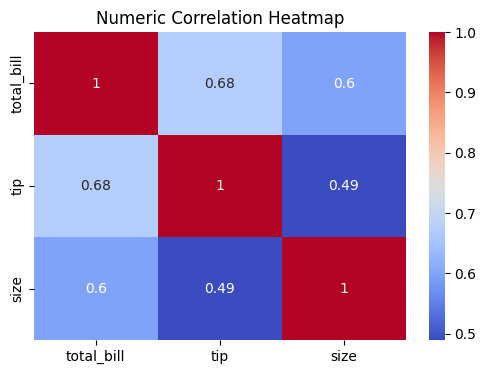

In [6]:
# 2. EDA - 수치형 히트맵
plt.figure(figsize=(6,4))
corr = df[['total_bill', 'tip', 'size']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Numeric Correlation Heatmap")
plt.show()

In [7]:
# 3. 라벨 인코딩
categorical_cols = ['sex', 'smoker', 'day', 'time']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [8]:
# 4. Feature / Target 분리
X = df.drop('tip', axis=1)
y = df['tip']

In [9]:
# 5. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# 6. 모델 학습
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# 7. 예측
y_pred = model.predict(X_test)

In [12]:
# 8. 성능 평가
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


R2 Score: 0.2299
RMSE: 0.9811


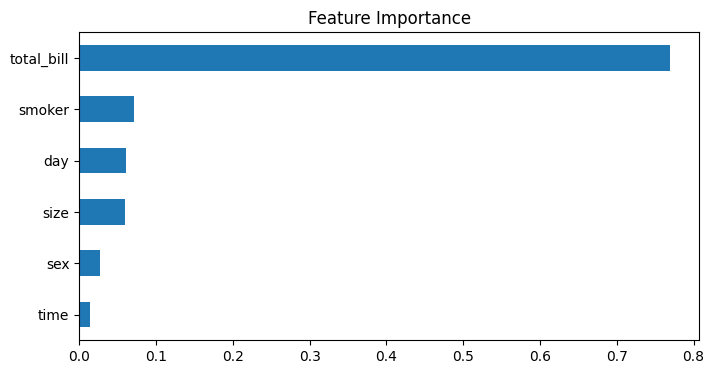

In [13]:
# 9. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,4))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

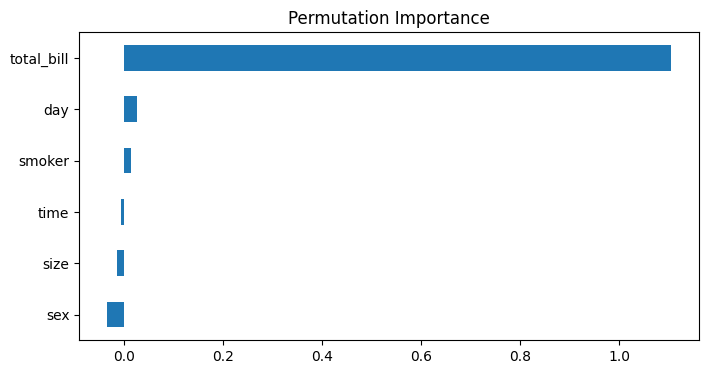

In [14]:
# 10. Permutation Importance
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

perm_importance = pd.Series(perm.importances_mean, index=X.columns)

plt.figure(figsize=(8,4))
perm_importance.sort_values().plot(kind='barh')
plt.title("Permutation Importance")
plt.show()

In [42]:
# 11. 모델 저장
joblib.dump(model, "../model/tips_model01.pkl")
joblib.dump(encoders, "../model/tips_labelencoders01.pkl")

print("\n모델 저장 완료!")


모델 저장 완료!


### 라벨인코딩 예시(개선후)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

import joblib

In [2]:
# 1. 데이터 로드
df = pd.read_csv("../dataset/tips.csv")

print("===== 데이터 정보 =====")
print(df.info())


===== 데이터 정보 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None


In [3]:
# 2. Feature Engineering (추가된 피처, 파생변수 : 기존에 없던 정보를 새로 만들어 모델 성는을 높이는 작업)
df['bill_per_person'] = df['total_bill'] / df['size']   # 1인당 금액
df['is_weekend'] = df['day'].isin(['Sat','Sun']).astype(int)  # 주말 여부  (True:1, False:0)
df['is_dinner'] = (df['time'] == 'Dinner').astype(int)  # 저녁 여부 (True:1, False:0)
df['tip_rate'] = df['tip'] / df['total_bill']  # 팁 비율

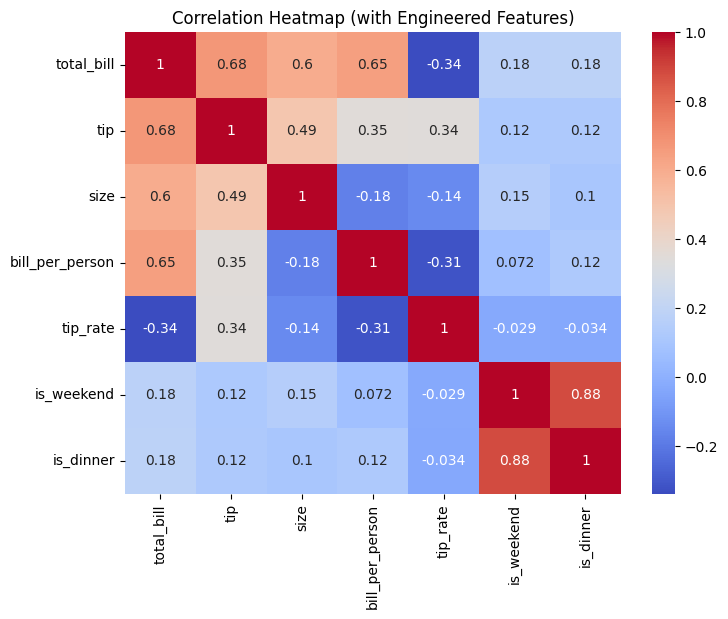

In [4]:
# 3. 히트맵 분석 (수치형 + 파생변수 포함)
plt.figure(figsize=(8,6))

numeric_cols = [
    'total_bill', 'tip', 'size',
    'bill_per_person', 'tip_rate',
    'is_weekend', 'is_dinner'
]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (with Engineered Features)")
plt.show()

In [5]:
# 4. 라벨 인코딩
categorical_cols = ['sex', 'smoker', 'day', 'time']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [6]:
# 5. Feature/Target X, y 분리
X = df.drop('tip', axis=1)
y = df['tip']

In [7]:
# 6. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# 7. 모델 학습 (하이퍼파라미터 튜닝 적용)
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
# 8. 예측 및 평가
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n===== 모델 성능 =====")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


===== 모델 성능 =====
R2 Score: 0.8222
RMSE: 0.4714


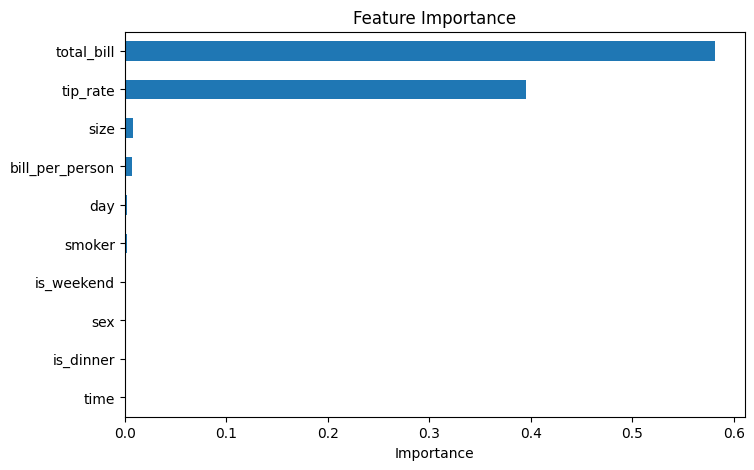

In [10]:
# 9. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

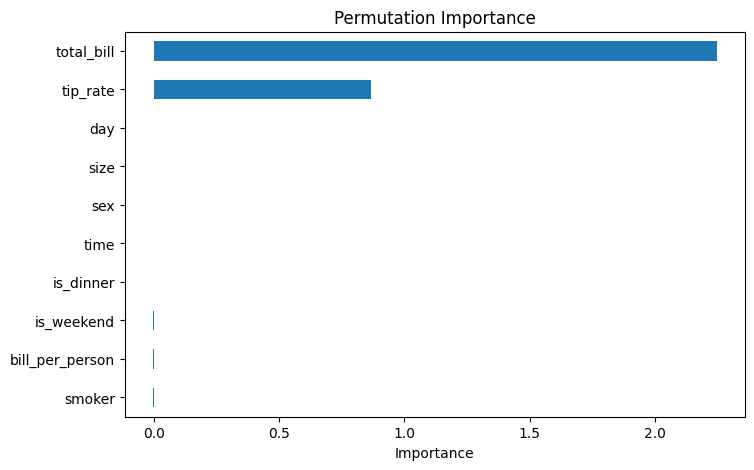

In [11]:
# 10. Permutation Importance
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
)

plt.figure(figsize=(8,5))
perm_importance.sort_values().plot(kind='barh')
plt.title("Permutation Importance")
plt.xlabel("Importance")
plt.show()

In [12]:
# 11. 모델 저장
joblib.dump(model, "../model/tips_model02.pkl")
joblib.dump(encoders, "../model/tips_labelencoders02.pkl")

['../model/tips_labelencoders02.pkl']

## 원핫인코딩

### Pandas get_dummies 버전

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

In [14]:
# 1. 데이터 로드
df = pd.read_csv("../dataset/tips.csv")

In [15]:
# 2. Feature Engineering
df['bill_per_person'] = df['total_bill'] / df['size']
df['is_weekend'] = df['day'].isin(['Sat','Sun']).astype(int)
df['is_dinner'] = (df['time'] == 'Dinner').astype(int)
df['tip_rate'] = df['tip'] / df['total_bill']

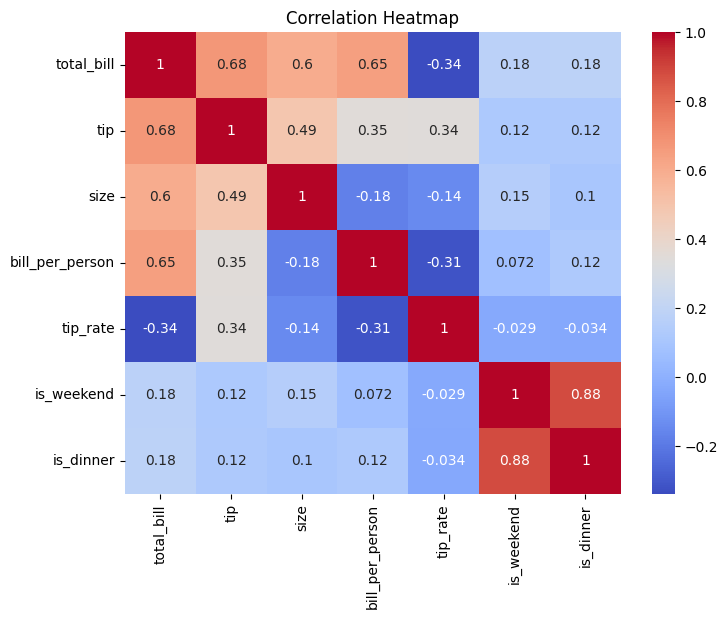

In [16]:
# 3. 히트맵
plt.figure(figsize=(8,6))

numeric_cols = [
    'total_bill', 'tip', 'size',
    'bill_per_person', 'tip_rate',
    'is_weekend', 'is_dinner'
]

corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
# 4. One-Hot Encoding (get_dummies)
categorical_cols = ['sex', 'smoker', 'day', 'time']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
# drop_first=True → 다중공선성 방지
print("\n===== One-Hot Encoding 이후 데이터 =====")
print(df.head())


===== One-Hot Encoding 이후 데이터 =====
   total_bill   tip  size  bill_per_person  is_weekend  is_dinner  tip_rate  \
0       16.99  1.01     2         8.495000           1          1  0.059447   
1       10.34  1.66     3         3.446667           1          1  0.160542   
2       21.01  3.50     3         7.003333           1          1  0.166587   
3       23.68  3.31     2        11.840000           1          1  0.139780   
4       24.59  3.61     4         6.147500           1          1  0.146808   

   sex_Male  smoker_Yes  day_Sat  day_Sun  day_Thur  time_Lunch  
0     False       False    False     True     False       False  
1      True       False    False     True     False       False  
2      True       False    False     True     False       False  
3      True       False    False     True     False       False  
4     False       False    False     True     False       False  


In [18]:
# 5. X, y 분리
X = df.drop('tip', axis=1)
y = df['tip']

In [19]:
# 6. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
# 7. 모델 학습
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
# 8. 평가
y_pred = model.predict(X_test)

print("\n===== 모델 성능 =====")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")


===== 모델 성능 =====
R2 Score: 0.8248
RMSE: 0.4679


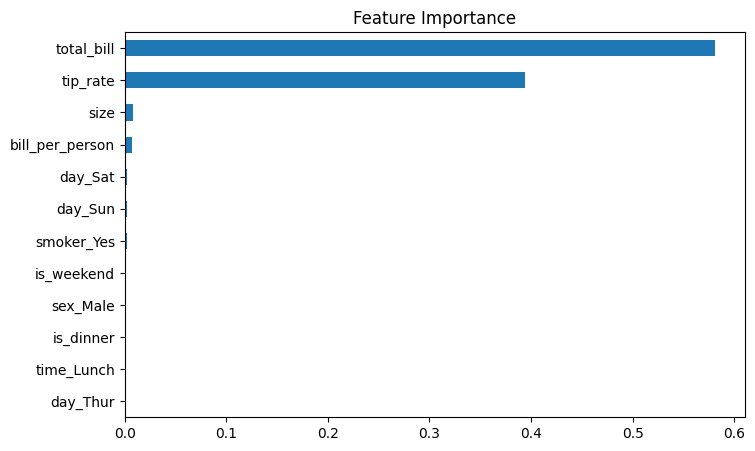

In [22]:
# 9. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

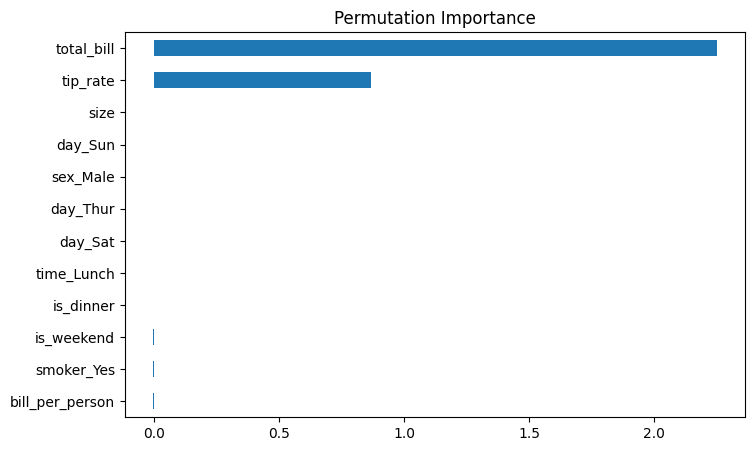

In [23]:
# 10. Permutation Importance
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

perm_importance = pd.Series(perm.importances_mean, index=X.columns)

plt.figure(figsize=(8,5))
perm_importance.sort_values().plot(kind='barh')
plt.title("Permutation Importance")
plt.show()

In [24]:
# 11. 모델 저장
joblib.dump(model, "../model/tips_model02.pkl")
joblib.dump(encoders, "../model/tips_labelencoders02.pkl")

['../model/tips_labelencoders02.pkl']

### sklearn OneHotEncoder 버전

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder

In [26]:
# 1. 데이터 로드
df = pd.read_csv("../dataset/tips.csv")

In [27]:
# 2. Feature Engineering
df['bill_per_person'] = df['total_bill'] / df['size']
df['is_weekend'] = df['day'].isin(['Sat','Sun']).astype(int)
df['is_dinner'] = (df['time'] == 'Dinner').astype(int)
df['tip_rate'] = df['tip'] / df['total_bill']

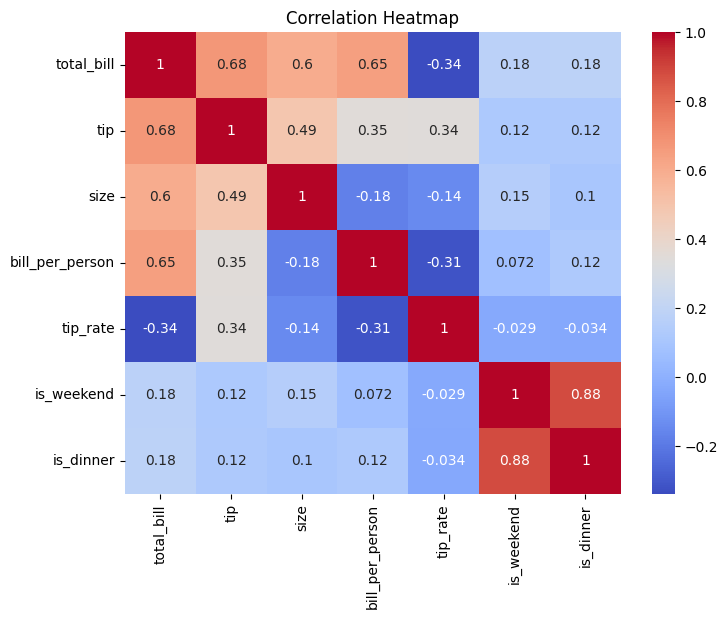

In [28]:
# 3. 히트맵
plt.figure(figsize=(8,6))

numeric_cols = [
    'total_bill', 'tip', 'size',
    'bill_per_person', 'tip_rate',
    'is_weekend', 'is_dinner'
]

corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [29]:
# 4. OneHotEncoder 적용
categorical_cols = ['sex', 'smoker', 'day', 'time']
numeric_cols = df.columns.difference(categorical_cols + ['tip'])

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)

df_encoded = pd.DataFrame(encoded, columns=encoded_cols)

# 기존 숫자형 + 인코딩 합치기
df_final = pd.concat([df[numeric_cols].reset_index(drop=True),
                      df_encoded.reset_index(drop=True)], axis=1)

print("\n===== OneHotEncoder 이후 데이터 =====")
print(df_final.head())


===== OneHotEncoder 이후 데이터 =====
   bill_per_person  is_dinner  is_weekend  size  tip_rate  total_bill  \
0         8.495000          1           1     2  0.059447       16.99   
1         3.446667          1           1     3  0.160542       10.34   
2         7.003333          1           1     3  0.166587       21.01   
3        11.840000          1           1     2  0.139780       23.68   
4         6.147500          1           1     4  0.146808       24.59   

   sex_Male  smoker_Yes  day_Sat  day_Sun  day_Thur  time_Lunch  
0       0.0         0.0      0.0      1.0       0.0         0.0  
1       1.0         0.0      0.0      1.0       0.0         0.0  
2       1.0         0.0      0.0      1.0       0.0         0.0  
3       1.0         0.0      0.0      1.0       0.0         0.0  
4       0.0         0.0      0.0      1.0       0.0         0.0  


In [30]:
# 5. X, y
X = df_final
y = df['tip']

In [31]:
# 6. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
# 7. 모델 학습
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train, y_train)

# 8. 평가
y_pred = model.predict(X_test)

print("\n===== 모델 성능 =====")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")


===== 모델 성능 =====
R2 Score: 0.8252
RMSE: 0.4674


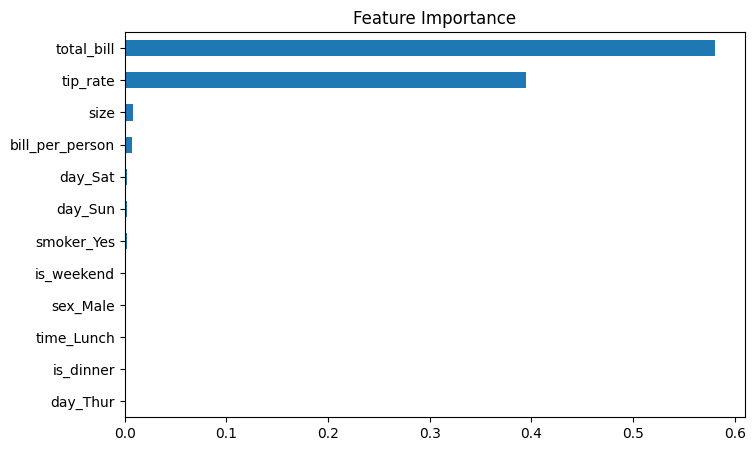

In [33]:
# 9. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

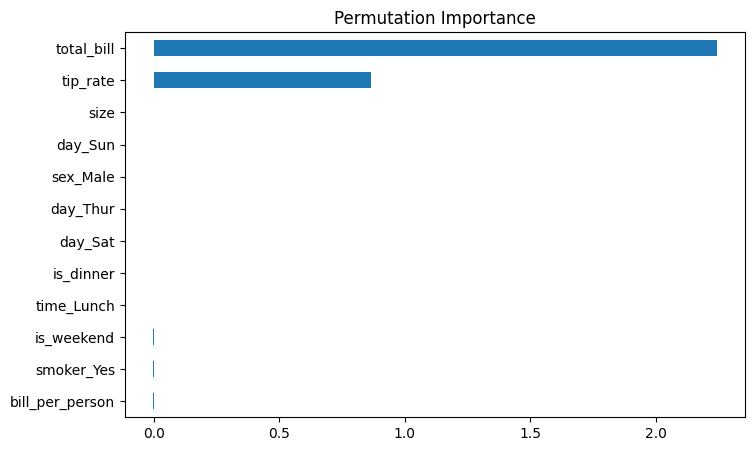

In [34]:
# 10. Permutation Importance
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

perm_importance = pd.Series(perm.importances_mean, index=X.columns)

plt.figure(figsize=(8,5))
perm_importance.sort_values().plot(kind='barh')
plt.title("Permutation Importance")
plt.show()

In [35]:
# 11. 모델 저장
joblib.dump(model, "../model/tips_model02.pkl")
joblib.dump(encoders, "../model/tips_labelencoders02.pkl")

['../model/tips_labelencoders02.pkl']

## SMOTE (클래스 불균형 시 오버샘플링 예시)

In [36]:
# 사전 설치 라이브러리 : pip install imbalanced-learn
# 1. 필요한 도구들 가져오기
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.datasets import make_classification

# 2. 가상의 불균형 데이터 만들기
# 전체 100개 중, 푸들(0)은 90%, 허스키(1)는 10%
X, y = make_classification(n_samples=100,
                           n_features=5,
                           weights=[0.9, 0.1],
                           random_state=42)

print(f"SMOTE 적용 전: {Counter(y)}")

# 3. SMOTE 마법 부리기 (허스키 늘리기)
# random_state는 결과를 똑같이 재현하기 위한 고정값
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("-" * 30)
print(f"SMOTE 적용 후: {Counter(y_resampled)}")


SMOTE 적용 전: Counter({np.int64(0): 90, np.int64(1): 10})
------------------------------
SMOTE 적용 후: Counter({np.int64(0): 90, np.int64(1): 90})


## diabetes(당뇨병) 데이터셋을 활용한 예제 (결과치가 안좋은 사례)

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [38]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
diabetes = pd.read_csv('../dataset/diabetes.csv')

In [40]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [39]:
# 특성(X)과 타겟(y) 분리
X = diabetes.drop('Outcome', axis=1)  # Outcome 열을 제외한 모든 특성
y = diabetes['Outcome']  # 타겟 변수

In [41]:
# 데이터 분할 (학습용 80%, 테스트용 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
# 선형회귀 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
# 테스트 세트에 대한 예측
y_pred = model.predict(X_test)

In [44]:
# 모델 성능 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [45]:
# 결과 출력
print('모델 성능 평가 결과:')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2 Score: {r2:.4f}')

모델 성능 평가 결과:
MSE: 0.1710
RMSE: 0.4136
R2 Score: 0.2550


In [46]:
# 각 특성의 계수(가중치) 출력
feature_coefficients = pd.DataFrame({
    '특성': X.columns,
    '계수': model.coef_
})
print('\n특성별 가중치:')
print(feature_coefficients)


특성별 가중치:
                         특성        계수
0               Pregnancies  0.010468
1                   Glucose  0.005634
2             BloodPressure -0.002281
3             SkinThickness  0.000532
4                   Insulin -0.000278
5                       BMI  0.015039
6  DiabetesPedigreeFunction  0.111263
7                       Age  0.006460


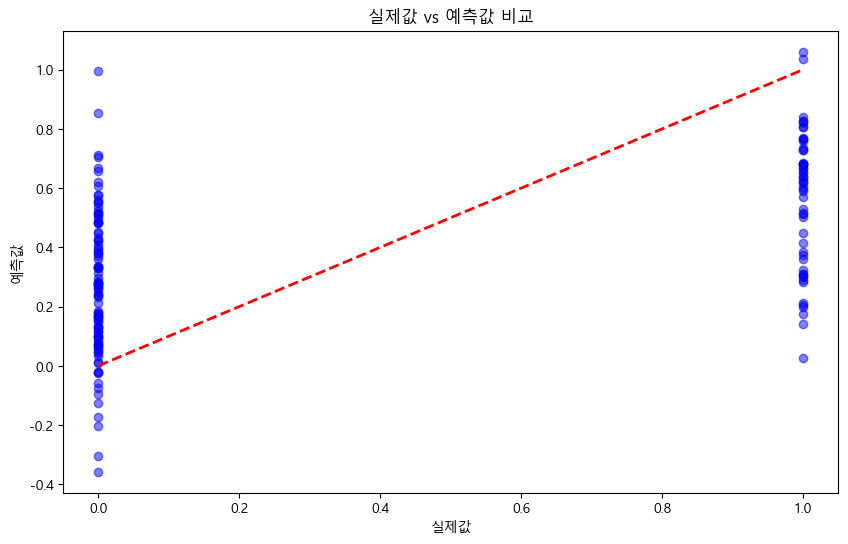

In [47]:
# 실제값과 예측값 비교 시각화
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.title('실제값 vs 예측값 비교')
plt.show()

In [48]:
# 예시: 첫 번째 테스트 데이터에 대한 예측
sample_data = X_test.iloc[0:1]
prediction = model.predict(sample_data)
print('\n새로운 데이터 예측 결과:')
print(f'예측값: {prediction[0]:.4f}')
print('실제 데이터:', sample_data.values[0])


새로운 데이터 예측 결과:
예측값: 0.3355
실제 데이터: [  6.    98.    58.    33.   190.    34.     0.43  43.  ]


## 랜덤포레스트를 활용한 당뇨병 데이터 알아보기 예제

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score   # cross_val_score:파라미터를 사전 지정해서 교차검증
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
# 데이터 로드
data = pd.read_csv('../dataset/diabetes.csv')

In [51]:
# 특성(X)과 타겟(y) 분리
X = data.drop('Outcome', axis=1)   # cf. 특정 피처만 선별할 때 : X = data[['bmi', 'Glucose', 'Age']]
y = data['Outcome']

In [52]:
# 데이터 전처리: 특성 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [53]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [54]:
# 랜덤 포레스트 모델 생성 및 학습
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
# 모델 저장
joblib.dump(model, 'diabetes_model.pkl')

['diabetes_model.pkl']

In [57]:
# 예측
y_pred = rf_model.predict(X_test)

In [58]:
# 교차 검증 수행
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=5)

In [59]:
# 특성 중요도 계산  (cf. permutation_importance : 다른 피처에 영향을 주는 정도를 측정)
feature_importance = pd.DataFrame({
    '특성': X.columns,
    '중요도': rf_model.feature_importances_
}).sort_values('중요도', ascending=False)

In [ ]:
# 결과 출력
print("모델 성능 평가:")
print("\n교차 검증 점수:")
print(f"평균 정확도: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print("\n분류 리포트:")
print(classification_report(y_test, y_pred))

모델 성능 평가:

교차 검증 점수:
평균 정확도: 0.7657 (+/- 0.0715)

분류 리포트:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        99
           1       0.62      0.62      0.62        55

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



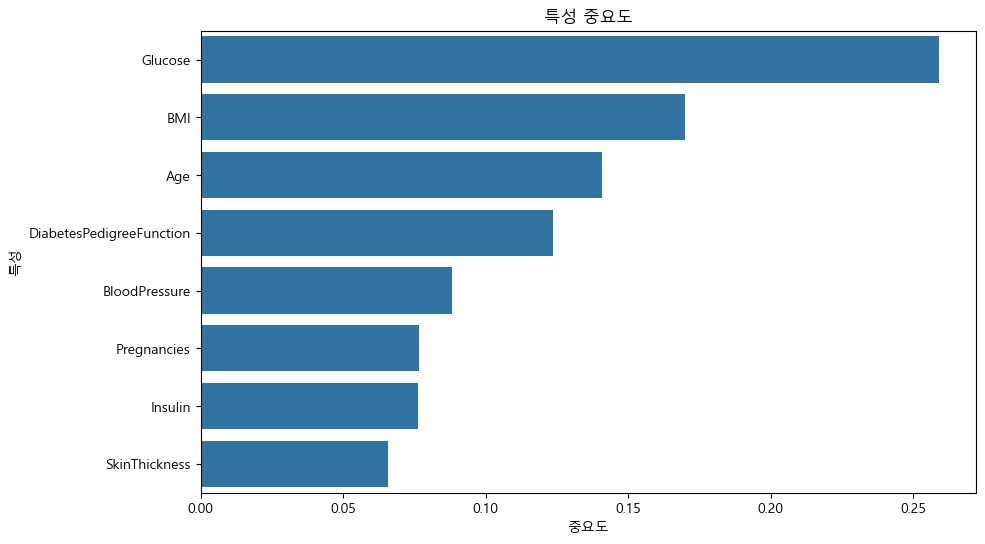

In [60]:
# 특성 중요도 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='중요도', y='특성', data=feature_importance)
plt.title('특성 중요도')
plt.show()

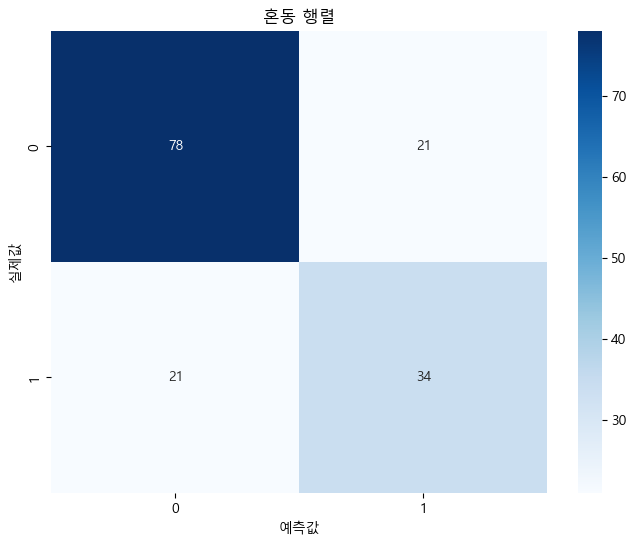

In [61]:
# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('혼동 행렬')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.show()

In [62]:
# 새로운 환자 데이터로 예측 예시
print("\n새로운 환자 데이터 예측 예시:")
# 임의의 환자 데이터 생성
new_patient = X_test.iloc[0:1]  # 첫번째 인덱스 값
prediction = rf_model.predict(new_patient)
prediction_prob = rf_model.predict_proba(new_patient)

print(f"예측 결과: {'당뇨병 환자' if prediction[0] == 1 else '정상'}")
print(f"당뇨병일 확률: {prediction_prob[0][1]:.2%}")   # 첫번째 샘플의 두번째 클래스


새로운 환자 데이터 예측 예시:
예측 결과: 정상
당뇨병일 확률: 31.00%


In [63]:
# 예측 신뢰도 분석
threshold_probs = rf_model.predict_proba(X_test)
confidence_scores = np.max(threshold_probs, axis=1)


예측 신뢰도 분포:


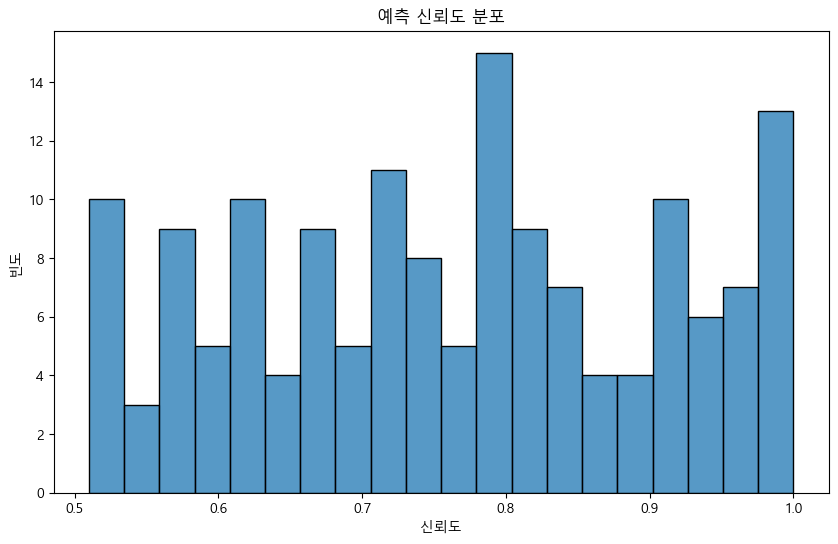

In [64]:
print("\n예측 신뢰도 분포:")
plt.figure(figsize=(10, 6))
sns.histplot(confidence_scores, bins=20)  # bins=20 : 데이터를 20개의 구간으로 보여줌
plt.title('예측 신뢰도 분포')
plt.xlabel('신뢰도')
plt.ylabel('빈도')
plt.show()

## 보스톤 집값 분석 예제

In [65]:
### 컬럼 설명 ###
# CRIM(타운별 1인당 범죄율), ZN(25,000평방피트 주택이 차지하는 비율), INDUS(비소매 상업지역 면적비율)
# CHAS(찰스강 인접 여부), NOX(일산화질소 농도), RM(주택 1가구당 평균 방 개수), AGE(1940년대 이전 주택 비율)
# DIS(보스턴 고용 센터까지의 가중거리), RAD(고속도로 접근성 지수), TAX(10,000달러당 재산세율), PTRATIO(타운별 학생교사 비율)
# B(타운별 흑인인구 비율 계산식), LSTAT(하위 계층의 비율), MEDV(주택의 중간 가격)

# 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [79]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{:.2f}'.format

In [67]:
# 데이터 로드
data = pd.read_csv('../dataset/HousingData.csv')

In [68]:
# 데이터 확인
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1,296,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2,242,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2,242,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3,222,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3,222,18.70,396.90,NaN,36.20


In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [70]:
# 결측값 확인 및 처리
print(data.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [71]:
data = data.dropna()  # 결측값 제거

In [72]:
# 결측값 확인 및 처리
print(data.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [73]:
# 주요 변수 선택
X = data[['CRIM', 'RM', 'TAX', 'LSTAT']]  # 입력 변수: CRIM(범죄율), RM(방개수), TAX(세금), LSTAT(하위계층비율
y = data['MEDV']  # 타겟 변수 (집값)

In [74]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [75]:
# 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [76]:
# 모델 평가
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [77]:
print(f'Mean Squared Error: {mse}')
print(f'R2 Score: {r2}')

Mean Squared Error: 41.01145441904804
R2 Score: 0.5137736507938266


In [78]:
# 회귀 계수 출력
print('회귀 계수:', model.coef_)
print('절편:', model.intercept_)

회귀 계수: [-0.08498347  5.59693339 -0.00824347 -0.42511164]
절편: -3.831014747888208


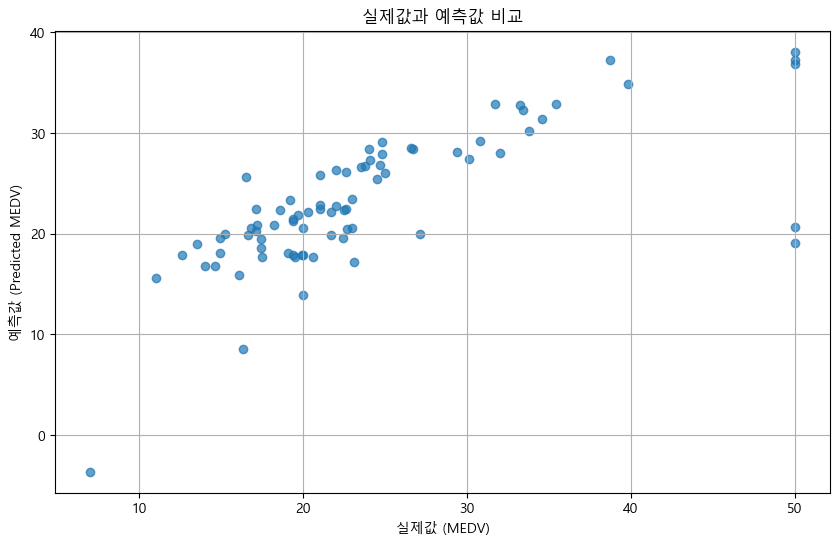

In [80]:
# 결과 시각화
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('실제값 (MEDV)')
plt.ylabel('예측값 (Predicted MEDV)')
plt.title('실제값과 예측값 비교')
plt.grid()
plt.show()

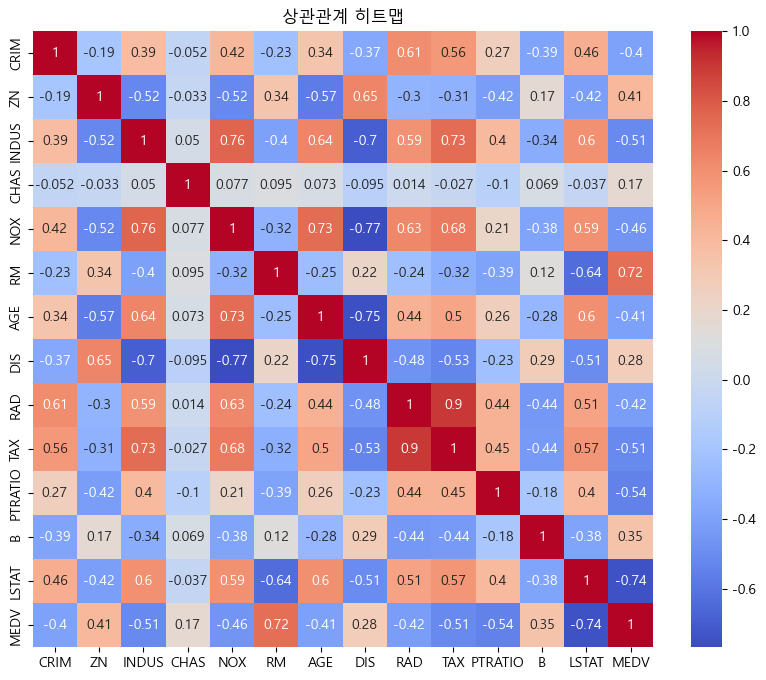

In [81]:
# 변수별 상관관계 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('상관관계 히트맵')
plt.show()

## 랜덤포레스트 모델 활용한 예제(cf. 다른 회귀모델 성능 비교)

In [82]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [83]:
# 데이터 로드
data = pd.read_csv('../dataset/HousingData.csv')

In [84]:
# 데이터 전처리
data = data.dropna()  # 결측값 제거
X = data[['CRIM', 'ZN', 'INDUS', 'RM', 'AGE', 'DIS', 'TAX', 'LSTAT']]
y = data['MEDV']

In [85]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
# 1. 랜덤 포레스트 모델
rf_model = RandomForestRegressor(random_state=42, n_estimators=100) # n_esimators : 모델을 구성하는 결정 트리의 개수
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

In [87]:
# 랜덤 포레스트 평가
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)
print(f"랜덤 포레스트 - MSE: {rf_mse:.2f}, R2: {rf_r2:.2f}")

랜덤 포레스트 - MSE: 28.59, R2: 0.66


In [88]:
# 2. 다른 모델 비교
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

In [89]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R2": r2}
    print(f"{name} - MSE: {mse:.2f}, R2: {r2:.2f}")

Linear Regression - MSE: 36.34, R2: 0.57
Decision Tree - MSE: 27.30, R2: 0.68


In [90]:
# 3. 최적 모델 선택 및 시각화
results["Random Forest"] = {"MSE": rf_mse, "R2": rf_r2}
# R2를 기준으로 최적 모델 선택 (높을수록 좋음)
best_model = max(results, key=lambda x: results[x]['R2'])
print("\n최적 모델:", best_model)

# MSE를 기준으로 최적 모델 선택 (낮을수록 좋음)
# best_model_mse = min(results, key=lambda x: results[x]['MSE'])
# print("[MSE 기준] 최적 모델:", best_model_mse)


최적 모델: Decision Tree


In [91]:
# 결과 시각화
r2_scores = [result["R2"] for result in results.values()]
model_names = list(results.keys())
model_names

['Linear Regression', 'Decision Tree', 'Random Forest']

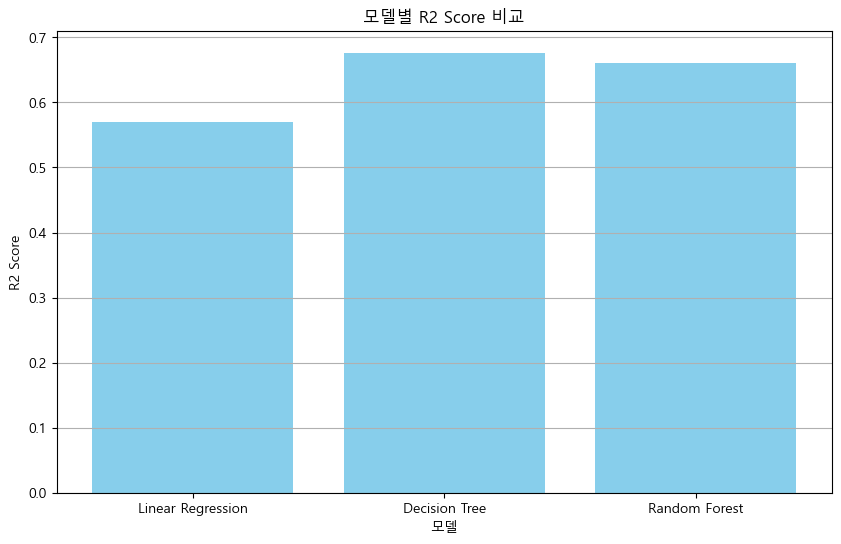

In [92]:
plt.figure(figsize=(10, 6))
plt.bar(model_names, r2_scores, color='skyblue')
plt.xlabel("모델")
plt.ylabel("R2 Score")
plt.title("모델별 R2 Score 비교")
plt.grid(axis='y')
plt.show()

In [93]:
# 4. 랜덤 포레스트 하이퍼파라미터 튜닝 (옵션)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [94]:
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [95]:
print("\n최적 하이퍼파라미터:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_
tuned_rf_y_pred = best_rf_model.predict(X_test)


최적 하이퍼파라미터: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}


In [96]:
# 튜닝된 모델 평가
tuned_rf_mse = mean_squared_error(y_test, tuned_rf_y_pred)
tuned_rf_r2 = r2_score(y_test, tuned_rf_y_pred)
print(f"튜닝된 랜덤 포레스트 - MSE: {tuned_rf_mse:.2f}, R2: {tuned_rf_r2:.2f}")

튜닝된 랜덤 포레스트 - MSE: 28.63, R2: 0.66


## 랜덤포레스트 모델 활용한 예제(streamlit을 활용한 당뇨병 예측)

In [ ]:
# 사전설치 : pip install streamlit
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib
import streamlit as st
import matplotlib as plt

In [ ]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
# 1. 데이터 로드 및 전처리
data = pd.read_csv('../dataset/diabetes.csv')

In [ ]:
# 선택된 feature만 사용
selected_features = ['Glucose', 'BMI', 'Age']
X = data[selected_features]
y = data['Outcome']  # 예측할 대상

In [ ]:
# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 2. 랜덤포레스트 모델 학습
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

In [ ]:
# 모델 저장
joblib.dump(model, 'diabetes_model.pkl')

In [ ]:
# 테스트 데이터로 정확도 확인
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy * 100:.2f}%')

In [ ]:
# 3. Streamlit 앱
st.title('당뇨병 예측 시스템')
st.write('Glucose, BMI, Age 값을 입력하여 당뇨병 예측을 해보세요.')


In [ ]:
# 사용자 입력받기
glucose = st.slider('Glucose (혈당 수치)', min_value=0, max_value=200, value=100)
bmi = st.slider('BMI (체질량지수)', min_value=0.0, max_value=50.0, value=25.0, step=0.1)
age = st.slider('Age (나이)', min_value=0, max_value=100, value=30)

In [ ]:
# 예측하기 버튼
if st.button('예측하기'):
    # 입력값을 모델에 전달
    model = joblib.load('diabetes_model.pkl')
    input_data = np.array([[glucose, bmi, age]])
    prediction = model.predict(input_data)[0]

    # 결과 출력
    if prediction == 1:
        st.write('예측 결과: 당뇨병 가능성이 높습니다.')
    else:
        st.write('예측 결과: 당뇨병 가능성이 낮습니다.')

## DB생성 및 연결 예제

In [ ]:
import pandas as pd

# CSV 파일 경로 설정
file_path = "../dataset/diabetes.csv"

# CSV 파일 읽기
df = pd.read_csv(file_path)

In [ ]:
# 데이터프레임 확인
df.head()

In [ ]:
# pymysql 설치 : pip install pymysql
import pymysql

In [ ]:
# MariaDB 연결 설정
def connect_to_mariadb():
    return pymysql.connect(
        host='localhost',          # MariaDB 서버 주소
        user='root',               # 사용자 이름
        password='0000000',  # 비밀번호
        database='test',  # 데이터베이스 이름
        charset='utf8mb4'
    )

In [ ]:
# 연결 테스트
connection = connect_to_mariadb()
print("MariaDB에 연결되었습니다!")
connection.close()

In [ ]:
# 테이블 및 컬럼 생성
def create_table_from_csv(connection, df, table_name):
    cursor = connection.cursor()

    # 테이블 생성 SQL 동적 생성
    columns = []
    for col, dtype in zip(df.columns, df.dtypes):
        if "int" in str(dtype):
            col_type = "INT"
        elif "float" in str(dtype):
            col_type = "FLOAT"
        else:
            col_type = "VARCHAR(255)"  # 문자열 타입 처리
        columns.append(f"`{col}` {col_type}")

    columns_sql = ", ".join(columns)
    create_table_sql = f"CREATE TABLE IF NOT EXISTS `{table_name}` ({columns_sql});"

    # 테이블 생성 실행
    cursor.execute(create_table_sql)
    connection.commit()
    print(f"테이블 '{table_name}'이(가) 생성되었습니다.")

In [ ]:
# 테이블 생성 실행
table_name = "diabetes"  # 생성할 테이블 이름
connection = connect_to_mariadb()
create_table_from_csv(connection, df, table_name)
connection.close()

In [ ]:
# CSV 데이터를 MariaDB로 업로드
def insert_data_to_table(connection, df, table_name):
    cursor = connection.cursor()

    # 데이터 삽입 SQL 동적 생성
    placeholders = ", ".join(["%s"] * len(df.columns))
    insert_sql = f"INSERT INTO `{table_name}` ({', '.join(df.columns)}) VALUES ({placeholders})"

    # 데이터 삽입 실행
    for _, row in df.iterrows():
        cursor.execute(insert_sql, tuple(row))

    connection.commit()
    print(f"테이블 '{table_name}'에 데이터가 삽입되었습니다.")

In [ ]:
# 데이터 삽입 실행
connection = connect_to_mariadb()
insert_data_to_table(connection, df, table_name)
connection.close()

In [ ]:
# MariaDB에서 데이터 읽기
def fetch_data_from_table(connection, table_name):
    query = f"SELECT * FROM `{table_name}`"
    df = pd.read_sql(query, connection)
    return df

In [ ]:
# 데이터 읽기
connection = connect_to_mariadb()
table_name = "diabetes"  # 불러올 테이블 이름

In [ ]:
# 데이터 읽기
df_from_db = fetch_data_from_table(connection, table_name)

In [ ]:
# 데이터 확인
print("MariaDB에서 불러온 데이터:")
print(df_from_db.head())

In [ ]:
connection.close()

## 미세먼지(PM10) 예측 예제

In [ ]:
# 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
# 데이터 로드
file_path = "../dataset/seoul_pm10.csv"  # 데이터 파일 경로
df = pd.read_csv(file_path, encoding='cp949')

In [ ]:
print("데이터 크기:", df.shape)
print("\n처음 5개 행:")
display(df.head())

In [ ]:
# 기본 데이터 정보 확인
print("\n데이터 기간:", df['date'].min(), "~", df['date'].max())
print("총 관측 수:", len(df))
print("지역 수:", df['area'].nunique())
print("\n결측치 개수:")
display(df.isnull().sum())

In [ ]:
# 데이터 전처리
# 날짜 변환
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# 결측치 처리
df['pm10'] = df['pm10'].fillna(df['pm10'].mean())
df['pm2.5'] = df['pm2.5'].fillna(df['pm2.5'].mean())

In [ ]:
# 시간 관련 피처 추가
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

In [ ]:
# 지역 원-핫 인코딩
df_encoded = pd.get_dummies(df, columns=['area'], prefix='area')

In [ ]:
# 전처리된 데이터 확인
print("\n전처리된 데이터 샘플:")
display(df_encoded.head())

In [ ]:
# PM10 모델 학습
features_pm10 = ['pm2.5', 'hour', 'day_of_week', 'month'] + [col for col in df_encoded.columns if col.startswith('area_')]
X_pm10 = df_encoded[features_pm10]
y_pm10 = df_encoded['pm10']

In [ ]:
# PM2.5 모델 학습
features_pm25 = ['pm10', 'hour', 'day_of_week', 'month'] + [col for col in df_encoded.columns if col.startswith('area_')]
X_pm25 = df_encoded[features_pm25]
y_pm25 = df_encoded['pm2.5']

In [ ]:
# 데이터 분할
X_train_pm10, X_test_pm10, y_train_pm10, y_test_pm10 = train_test_split(X_pm10, y_pm10, test_size=0.2, random_state=42)
X_train_pm25, X_test_pm25, y_train_pm25, y_test_pm25 = train_test_split(X_pm25, y_pm25, test_size=0.2, random_state=42)

In [ ]:
# 모델 학습
model_pm10 = LinearRegression()
model_pm25 = LinearRegression()

In [ ]:
model_pm10.fit(X_train_pm10, y_train_pm10)
model_pm25.fit(X_train_pm25, y_train_pm25)

In [ ]:
# 모델 평가
y_pred_pm10 = model_pm10.predict(X_test_pm10)
y_pred_pm25 = model_pm25.predict(X_test_pm25)

In [ ]:
print("\nPM10 모델 성능:")
print(f"R² Score: {r2_score(y_test_pm10, y_pred_pm10):.4f}")
print(f"MSE: {mean_squared_error(y_test_pm10, y_pred_pm10):.4f}")

In [ ]:
print("\nPM2.5 모델 성능:")
print(f"R² Score: {r2_score(y_test_pm25, y_pred_pm25):.4f}")
print(f"MSE: {mean_squared_error(y_test_pm25, y_pred_pm25):.4f}")

In [ ]:
# 2023년 1월 1일 예측을 위한 함수
def create_prediction_data(area):
    predictions = []
    for hour in range(24):
        pred_data = {
            'hour': hour,
            'day_of_week': 6,  # 2023년 1월 1일은 일요일
            'month': 1
        }

        # 지역 원-핫 인코딩 추가
        for area_col in [col for col in df_encoded.columns if col.startswith('area_')]:
            pred_data[area_col] = 1 if area_col == f'area_{area}' else 0

        predictions.append(pred_data)

    return pd.DataFrame(predictions)

In [ ]:
# 사용자 입력 - 지역 선택
areas = sorted(df['area'].unique())  # unique : 중복제거
print("\n예측 가능한 지역:")
display(areas)

In [ ]:
# 예시로 한 지역 선택 (실제로는 사용자가 선택)
selected_area = areas[0]  # 첫 번째 지역 선택
print(f"\n선택된 지역: {selected_area}")

In [ ]:
# 2023년 1월 1일 예측
future_data = create_prediction_data(selected_area)
pm10_predictions = []
pm25_predictions = []

In [ ]:
# 반복 예측 (PM10과 PM2.5 상호 의존성 처리)
for hour in range(24):
    hour_data = future_data.iloc[[hour]].copy()

    # 초기값 설정
    hour_data['pm2.5'] = df['pm2.5'].mean()
    hour_data['pm10'] = df['pm10'].mean()

    # 반복 예측으로 정확도 향상
    for _ in range(3):
        pm10_pred = model_pm10.predict(hour_data[features_pm10])
        pm25_pred = model_pm25.predict(hour_data[features_pm25])

        hour_data['pm10'] = pm10_pred
        hour_data['pm2.5'] = pm25_pred

    pm10_predictions.append(pm10_pred[0])
    pm25_predictions.append(pm25_pred[0])

In [ ]:
# 예측 결과 시각화
plt.figure(figsize=(15, 10))

In [ ]:
# PM10 그래프
plt.subplot(2, 1, 1)
plt.plot(range(24), pm10_predictions, marker='o', linewidth=2, markersize=8)
plt.title(f'{selected_area} PM10 예측 (2023년 1월 1일)')
plt.xlabel('시간')
plt.ylabel('농도 (μg/m³)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# PM2.5 그래프
plt.subplot(2, 1, 2)
plt.plot(range(24), pm25_predictions, marker='o', linewidth=2, markersize=8, color='orange')
plt.title(f'{selected_area} PM2.5 예측 (2023년 1월 1일)')
plt.xlabel('시간')
plt.ylabel('농도 (μg/m³)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 예측 결과 통계
print("\nPM10 예측 통계:")
print(f"평균: {np.mean(pm10_predictions):.1f} μg/m³")
print(f"최대: {np.max(pm10_predictions):.1f} μg/m³")
print(f"최소: {np.min(pm10_predictions):.1f} μg/m³")

In [ ]:
print("\nPM2.5 예측 통계:")
print(f"평균: {np.mean(pm25_predictions):.1f} μg/m³")
print(f"최대: {np.max(pm25_predictions):.1f} μg/m³")
print(f"최소: {np.min(pm25_predictions):.1f} μg/m³")

In [ ]:
# 시간별 예측값 데이터프레임 생성
hourly_predictions = pd.DataFrame({
    '시간': range(24),
    'PM10': [f"{x:.1f}" for x in pm10_predictions],
    'PM2.5': [f"{x:.1f}" for x in pm25_predictions]
})

In [ ]:
print("\n시간별 예측값:")
display(hourly_predictions)

In [ ]:
# 실제값과 예측값 비교 시각화 (테스트 데이터 기준)
plt.figure(figsize=(15, 10))

In [ ]:
# PM10 비교
plt.subplot(2, 1, 1)
plt.scatter(y_test_pm10, y_pred_pm10, alpha=0.5)
plt.plot([y_test_pm10.min(), y_test_pm10.max()],
         [y_test_pm10.min(), y_test_pm10.max()],
         'r--', lw=2)
plt.xlabel('실제 PM10')
plt.ylabel('예측 PM10')
plt.title('PM10 실제값 vs 예측값 (테스트 데이터)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# PM2.5 비교
plt.subplot(2, 1, 2)
plt.scatter(y_test_pm25, y_pred_pm25, alpha=0.5, color='orange')
plt.plot([y_test_pm25.min(), y_test_pm25.max()],
         [y_test_pm25.min(), y_test_pm25.max()],
         'r--', lw=2)
plt.xlabel('실제 PM2.5')
plt.ylabel('예측 PM2.5')
plt.title('PM2.5 실제값 vs 예측값 (테스트 데이터)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 미세먼지(PM10) 예측 예제 (랜덤포레스트 모델)

In [ ]:
# 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
# 데이터 로드
file_path = "../dataset/seoul_pm10.csv"  # 데이터 파일 경로
df = pd.read_csv(file_path, encoding='cp949')
print("데이터 크기:", df.shape)
print("\n처음 5개 행:")
display(df.head())

데이터 크기: (227759, 4)

처음 5개 행:


,date,area,pm10,pm2.5
0,2022-12-31 23:00,강남구,57.00,44.00
1,2022-12-31 23:00,강동구,68.00,55.00
2,2022-12-31 23:00,강북구,59.00,42.00
3,2022-12-31 23:00,강서구,62.00,40.00
4,2022-12-31 23:00,관악구,57.00,38.00


In [ ]:
# 기본 데이터 정보 확인
print("\n데이터 기간:", df['date'].min(), "~", df['date'].max())
print("총 관측 수:", len(df))
print("지역 수:", df['area'].nunique())


데이터 기간: 2022-01-01 0:00 ~ 2022-12-31 9:00
총 관측 수: 227759
지역 수: 26


In [ ]:
# 결측치 개수 출력 수정 (ll() -> df.isnull())
print("\n결측치 개수:")
print(df.isnull().sum())


결측치 개수:
date        0
area        0
pm10     4916
pm2.5    4247
dtype: int64


In [ ]:
# 데이터 전처리
# 날짜 변환
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# 결측치 처리
df['pm10'] = df['pm10'].fillna(df['pm10'].mean())
df['pm2.5'] = df['pm2.5'].fillna(df['pm2.5'].mean())

In [ ]:
# 시간 관련 피처 추가
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

In [ ]:
# 지역 원-핫 인코딩
df_encoded = pd.get_dummies(df, columns=['area'], prefix='area')

In [ ]:
# 전처리된 데이터 확인
print("\n전처리된 데이터 샘플:")
display(df_encoded.head())


전처리된 데이터 샘플:


,date,pm10,pm2.5,hour,day_of_week,month,area_강남구,area_강동구,area_강북구,area_강서구,...,area_성북구,area_송파구,area_양천구,area_영등포구,area_용산구,area_은평구,area_종로구,area_중구,area_중랑구,area_평균
0,2022-12-31 23:00:00,57.00,44.00,23,5,12,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2022-12-31 23:00:00,68.00,55.00,23,5,12,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2022-12-31 23:00:00,59.00,42.00,23,5,12,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2022-12-31 23:00:00,62.00,40.00,23,5,12,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,2022-12-31 23:00:00,57.00,38.00,23,5,12,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# PM10 모델 학습
features_pm10 = ['pm2.5', 'hour', 'day_of_week', 'month'] + [col for col in df_encoded.columns if col.startswith('area_')]
X_pm10 = df_encoded[features_pm10]
y_pm10 = df_encoded['pm10']


In [ ]:
# PM2.5 모델 학습
features_pm25 = ['pm10', 'hour', 'day_of_week', 'month'] + [col for col in df_encoded.columns if col.startswith('area_')]
X_pm25 = df_encoded[features_pm25]
y_pm25 = df_encoded['pm2.5']

In [ ]:
# 데이터 분할
X_train_pm10, X_test_pm10, y_train_pm10, y_test_pm10 = train_test_split(X_pm10, y_pm10, test_size=0.2, random_state=42)
X_train_pm25, X_test_pm25, y_train_pm25, y_test_pm25 = train_test_split(X_pm25, y_pm25, test_size=0.2, random_state=42)

In [ ]:
# 모델 학습 (RandomForestRegressor 사용)
model_pm10 = RandomForestRegressor(n_estimators=100, random_state=42)
model_pm25 = RandomForestRegressor(n_estimators=100, random_state=42)
model_pm10.fit(X_train_pm10, y_train_pm10)
model_pm25.fit(X_train_pm25, y_train_pm25)

RandomForestRegressor(random_state=42)

In [ ]:
# 모델 평가
y_pred_pm10 = model_pm10.predict(X_test_pm10)
y_pred_pm25 = model_pm25.predict(X_test_pm25)

In [ ]:
print("\nPM10 모델 성능:")
print(f"R² Score: {r2_score(y_test_pm10, y_pred_pm10):.4f}")
print(f"MSE: {mean_squared_error(y_test_pm10, y_pred_pm10):.4f}")


PM10 모델 성능:
R² Score: 0.8372
MSE: 82.3474


In [ ]:
print("\nPM2.5 모델 성능:")
print(f"R² Score: {r2_score(y_test_pm25, y_pred_pm25):.4f}")
print(f"MSE: {mean_squared_error(y_test_pm25, y_pred_pm25):.4f}")


PM2.5 모델 성능:
R² Score: 0.9131
MSE: 16.6246


In [ ]:
# 2023년 1월 1일 예측을 위한 함수
def create_prediction_data(area):
    predictions = []
    for hour in range(24):
        pred_data = {
            'hour': hour,
            'day_of_week': 6,  # 2023년 1월 1일은 일요일
            'month': 1
        }

        # 지역 원-핫 인코딩 추가
        for area_col in [col for col in df_encoded.columns if col.startswith('area_')]:
            pred_data[area_col] = 1 if area_col == f'area_{area}' else 0

        predictions.append(pred_data)

    return pd.DataFrame(predictions)

In [ ]:
# 사용자 입력 - 지역 선택
areas = sorted(df['area'].unique())
print("\n예측 가능한 지역:")
display(areas)


예측 가능한 지역:


['강남구',
 '강동구',
 '강북구',
 '강서구',
 '관악구',
 '광진구',
 '구로구',
 '금천구',
 '노원구',
 '도봉구',
 '동대문구',
 '동작구',
 '마포구',
 '서대문구',
 '서초구',
 '성동구',
 '성북구',
 '송파구',
 '양천구',
 '영등포구',
 '용산구',
 '은평구',
 '종로구',
 '중구',
 '중랑구',
 '평균']

In [ ]:
# 예시로 한 지역 선택 (실제로는 사용자가 선택)
selected_area = areas[0]  # 첫 번째 지역 선택
print(f"\n선택된 지역: {selected_area}")


선택된 지역: 강남구


In [ ]:
# 2023년 1월 1일 예측
future_data = create_prediction_data(selected_area)
pm10_predictions = []
pm25_predictions = []

In [ ]:
# 반복 예측 (PM10과 PM2.5 상호 의존성 처리)
for hour in range(24):
    hour_data = future_data.iloc[[hour]].copy()

    # 초기값 설정
    hour_data['pm2.5'] = df['pm2.5'].mean()
    hour_data['pm10'] = df['pm10'].mean()

    # 반복 예측으로 정확도 향상
    for _ in range(3):
        pm10_pred = model_pm10.predict(hour_data[features_pm10])
        pm25_pred = model_pm25.predict(hour_data[features_pm25])

        hour_data['pm10'] = pm10_pred
        hour_data['pm2.5'] = pm25_pred

    pm10_predictions.append(pm10_pred[0])
    pm25_predictions.append(pm25_pred[0])

In [ ]:
# 예측 결과 시각화
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<ipython-input-24-8361267258c0>:8: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-24-8361267258c0>:8: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-24-8361267258c0>:8: UserWarning: Glyph 45453 (\N{HANGUL SYLLABLE NONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-24-8361267258c0>:8: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-24-8361267258c0>:8: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-24-8361267258c0>:8: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-24-8361267258c0>:8: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input

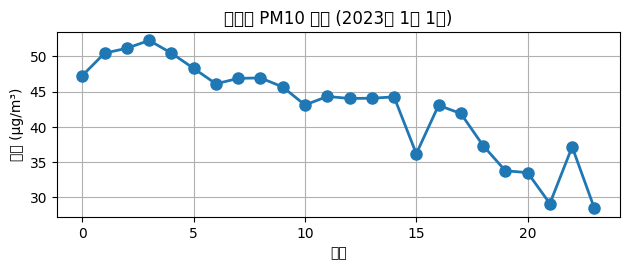

In [ ]:
# PM10 그래프
plt.subplot(2, 1, 1)
plt.plot(range(24), pm10_predictions, marker='o', linewidth=2, markersize=8)
plt.title(f'{selected_area} PM10 예측 (2023년 1월 1일)')
plt.xlabel('시간')
plt.ylabel('농도 (μg/m³)')
plt.grid(True)
plt.tight_layout()
plt.show()

<ipython-input-25-64427f5b89fa>:8: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-25-64427f5b89fa>:8: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-25-64427f5b89fa>:8: UserWarning: Glyph 45453 (\N{HANGUL SYLLABLE NONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-25-64427f5b89fa>:8: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-25-64427f5b89fa>:8: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-25-64427f5b89fa>:8: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-25-64427f5b89fa>:8: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input

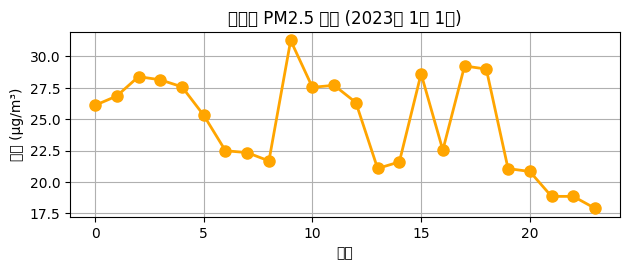

In [ ]:
# PM2.5 그래프
plt.subplot(2, 1, 2)
plt.plot(range(24), pm25_predictions, marker='o', linewidth=2, markersize=8, color='orange')
plt.title(f'{selected_area} PM2.5 예측 (2023년 1월 1일)')
plt.xlabel('시간')
plt.ylabel('농도 (μg/m³)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 예측 결과 통계
print("\nPM10 예측 통계:")
print(f"평균: {np.mean(pm10_predictions):.1f} μg/m³")
print(f"최대: {np.max(pm10_predictions):.1f} μg/m³")
print(f"최소: {np.min(pm10_predictions):.1f} μg/m³")

print("\nPM2.5 예측 통계:")
print(f"평균: {np.mean(pm25_predictions):.1f} μg/m³")
print(f"최대: {np.max(pm25_predictions):.1f} μg/m³")
print(f"최소: {np.min(pm25_predictions):.1f} μg/m³")


PM10 예측 통계:
평균: 42.7 μg/m³
최대: 52.3 μg/m³
최소: 28.4 μg/m³

PM2.5 예측 통계:
평균: 24.6 μg/m³
최대: 31.3 μg/m³
최소: 17.9 μg/m³


In [ ]:
# 시간별 예측값 데이터프레임 생성
hourly_predictions = pd.DataFrame({
    '시간': range(24),
    'PM10': [f"{x:.1f}" for x in pm10_predictions],
    'PM2.5': [f"{x:.1f}" for x in pm25_predictions]
})

print("\n시간별 예측값:")
display(hourly_predictions)


시간별 예측값:


,시간,PM10,PM2.5
0,0,47.3,26.1
1,1,50.5,26.8
2,2,51.2,28.4
3,3,52.3,28.1
4,4,50.5,27.6
5,5,48.3,25.3
6,6,46.1,22.5
7,7,46.9,22.3
8,8,46.9,21.7
9,9,45.6,31.3


In [ ]:
# 실제값과 예측값 비교 시각화 (테스트 데이터 기준)
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<ipython-input-29-551bda00af24>:11: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-29-551bda00af24>:11: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-29-551bda00af24>:11: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-29-551bda00af24>:11: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-29-551bda00af24>:11: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-29-551bda00af24>:11: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-29-551bda00af24>:11: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipytho

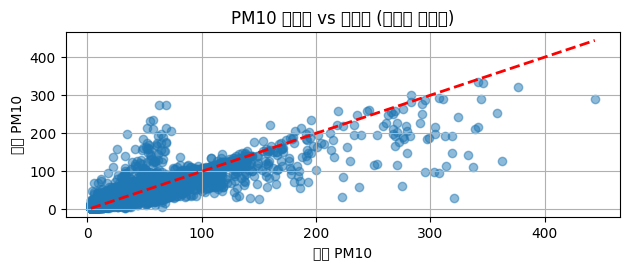

In [ ]:
# PM10 비교
plt.subplot(2, 1, 1)
plt.scatter(y_test_pm10, y_pred_pm10, alpha=0.5)
plt.plot([y_test_pm10.min(), y_test_pm10.max()],
         [y_test_pm10.min(), y_test_pm10.max()],
         'r--', lw=2)
plt.xlabel('실제 PM10')
plt.ylabel('예측 PM10')
plt.title('PM10 실제값 vs 예측값 (테스트 데이터)')
plt.grid(True)
plt.tight_layout()
plt.show()

<ipython-input-30-cd774aad0688>:11: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-30-cd774aad0688>:11: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-30-cd774aad0688>:11: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-30-cd774aad0688>:11: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-30-cd774aad0688>:11: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-30-cd774aad0688>:11: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-30-cd774aad0688>:11: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipytho

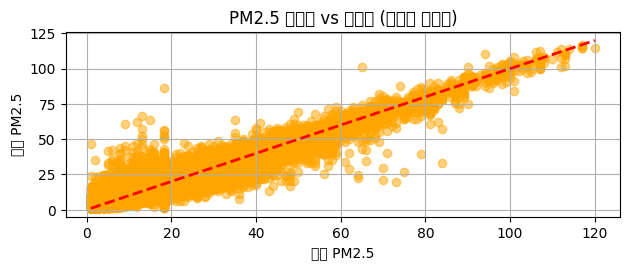

In [ ]:
# PM2.5 비교
plt.subplot(2, 1, 2)
plt.scatter(y_test_pm25, y_pred_pm25, alpha=0.5, color='orange')
plt.plot([y_test_pm25.min(), y_test_pm25.max()],
         [y_test_pm25.min(), y_test_pm25.max()],
         'r--', lw=2)
plt.xlabel('실제 PM2.5')
plt.ylabel('예측 PM2.5')
plt.title('PM2.5 실제값 vs 예측값 (테스트 데이터)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 직원 퇴사예측 예제


In [98]:
# 컬럼 설명 : satisfaction_level(직원만족도점수), last_evaluation(고용주평가점수), numbers_projects(할당된 프로젝트수)
# average_monthly_hours(한달동안 직원이 일한 평균시간), time_spent_company(회사에서 근무한 연수), work_accident(근무중 사고유무무)
# promotion_last_5years(지난 5년 직원이 승진했는지 여부), Departments(부서), Salary(월급수준 낮음, 중간, 높음), left(직원퇴사 여부)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt

In [99]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{:.2f}'.format

In [100]:
# 데이터 로드
df = pd.read_csv('../dataset/HR_comma_sep.csv', encoding='cp949')

In [101]:
# 데이터 확인
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [102]:
# 'left' 열이 정수형인지 확인하고 필요시 변환
if df['left'].dtype != 'int64':
    df['left'] = df['left'].astype(int)

In [103]:
# 범주형 변수 확인 및 전처리
# 'Departments ' 끝에 공백 제거
df.rename(columns={'Departments ': 'Departments'}, inplace=True)

In [104]:
# 원-핫 인코딩 (범주형 변수 처리)
df = pd.get_dummies(df, columns=['Departments', 'salary'], drop_first=True) # 첫 번째 범주를 삭제하여 다중공선성을 방지

In [105]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments_RandD,Departments_accounting,Departments_hr,Departments_management,Departments_marketing,Departments_product_mng,Departments_sales,Departments_support,Departments_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


In [106]:
# 독립 변수(X)와 종속 변수(y) 설정
X = df.drop('left', axis=1)
y = df['left']

In [107]:
# 데이터 분할 (Train: 80%, Test: 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [108]:
# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [109]:
# 모델 학습 - 랜덤 포레스트
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [110]:
# 예측
y_pred = model.predict(X_test_scaled)

In [111]:
# 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.99

Confusion Matrix:
[[2286    8]
 [  27  679]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2294
           1       0.99      0.96      0.97       706

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



In [112]:
# Feature Importance (중요 변수 확인)
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [113]:
print("\nFeature Importances:")
print(feature_importances)


Feature Importances:
                    Feature  Importance
0        satisfaction_level        0.33
2            number_project        0.19
4        time_spend_company        0.18
3      average_montly_hours        0.14
1           last_evaluation        0.12
5             Work_accident        0.01
16               salary_low        0.01
15    Departments_technical        0.00
17            salary_medium        0.00
13        Departments_sales        0.00
14      Departments_support        0.00
7         Departments_RandD        0.00
8    Departments_accounting        0.00
6     promotion_last_5years        0.00
9            Departments_hr        0.00
10   Departments_management        0.00
11    Departments_marketing        0.00
12  Departments_product_mng        0.00


In [114]:
############ ROC 커브 시각화 ###############
from sklearn.metrics import roc_curve, auc
# 1. 모델의 예측 확률 가져오기 (양성 클래스, 즉 'left'가 1일 확률)
# predict_proba()는 각 클래스에 대한 확률을 반환하며, 두 번째 열(인덱스 1)이 양성 클래스(1)의 확률임
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [115]:
# 2. ROC curve 계산
# fpr: False Positive Rate (거짓 양성률)
# tpr: True Positive Rate (참 양성률)
# thresholds: 임계값 (분류 결정 기준이 되는 값)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [116]:
# 3. AUC (Area Under the Curve) 계산
# AUC는 ROC 곡선 아래 면적으로, 1에 가까울수록 모델의 성능이 좋다고 평가
roc_auc = auc(fpr, tpr)

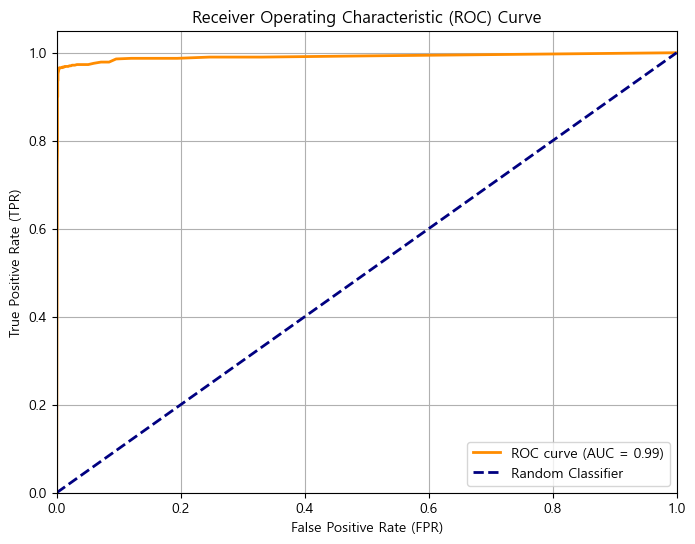

In [117]:
# 4. ROC curve 시각화
plt.figure(figsize=(8, 6)) # 그래프 크기 설정
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})') # ROC 곡선 그리기
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier') # 대각선 (랜덤 분류기) 그리기
plt.xlim([0.0, 1.0]) # x축 범위 설정
plt.ylim([0.0, 1.05]) # y축 범위 설정
plt.xlabel('False Positive Rate (FPR)') # x축 라벨
plt.ylabel('True Positive Rate (TPR)') # y축 라벨
plt.title('Receiver Operating Characteristic (ROC) Curve') # 그래프 제목
plt.legend(loc='lower right') # 범례 위치 설정
plt.grid(True) # 그리드 표시
plt.show() # 그래프 보여주기

## 자전거 수요량 예측 (XGBoost)

데이터 크기: (10886, 12)
Fitting 3 folds for each of 128 candidates, totalling 384 fits
Best Parameters: {'alpha': 1, 'colsample_bytree': 0.8, 'lambda': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
RMSE: 39.47
R2 Score: 0.9528


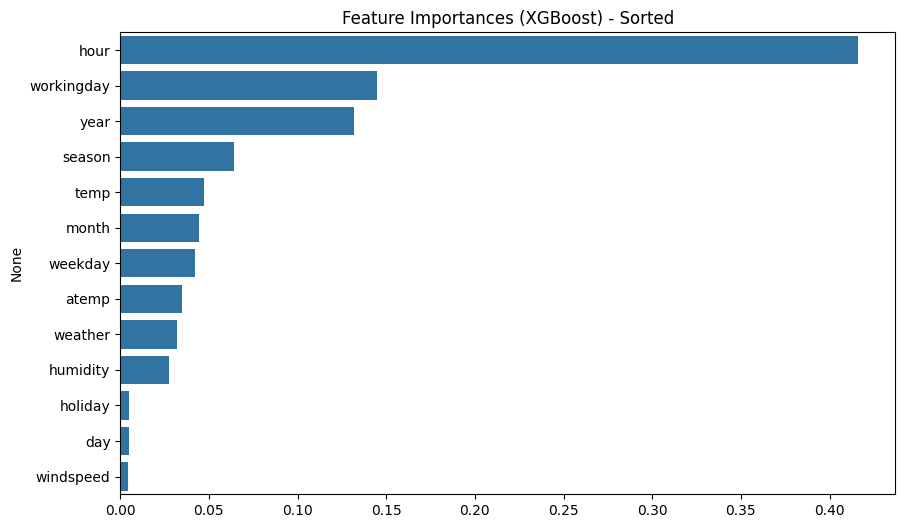

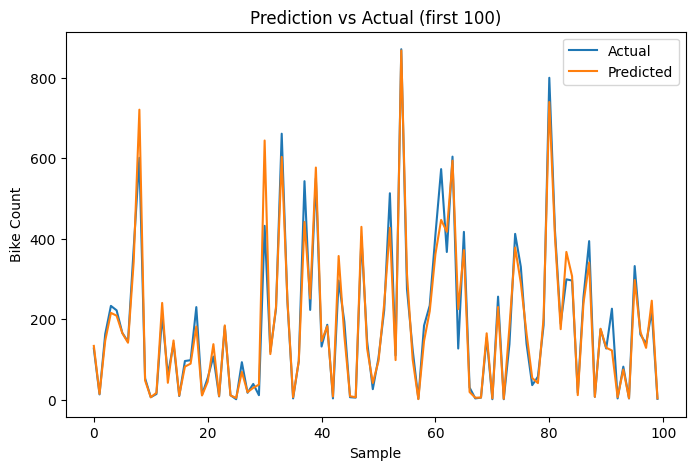

In [ ]:
# 사전설치 : pip install xgboost
## 컬럼명,설명  ##
# season,계절 (1: 봄, 2: 여름, 3: 가을, 4: 겨울). 범주형 데이터.
# holiday,공휴일 여부 (0: 공휴일 아님, 1: 공휴일). 이진(binary) 데이터.
# workingday,근무일 여부 (0: 근무일 아님 (주말 또는 공휴일), 1: 근무일). 이진(binary) 데이터.
# weather,날씨 상태 (1: 맑음, 약간 흐림; 2: 안개, 흐림; 3: 약한 눈/비, 천둥번개; 4: 폭우/폭설, 안개). 범주형 데이터.
# temp,정규화된 온도 (섭씨). 0과 1 사이로 스케일링된 값. 실제 온도를 얻으려면 이 값에 스케일링 인자를 곱해야 할 수 있음.
# atemp,정규화된 체감 온도 (섭씨). 0과 1 사이로 스케일링된 값. 체감 온도는 바람, 습도 등을 고려한 온도.
# humidity,정규화된 습도. 0과 1 사이로 스케일링된 값.
# windspeed,정규화된 풍속. 0과 1 사이로 스케일링된 값.
# casual,비등록 사용자(회원이 아닌 사용자)의 자전거 대여 건수. 숫자형 데이터. 주로 예측의 대상이 될 수 있음.
# registered,등록 사용자(회원)의 자전거 대여 건수. 숫자형 데이터. 주로 예측의 대상이 될 수 있음.
# count,총 자전거 대여 건수 (casual + registered). 숫자형 데이터. 이 데이터셋에서 주요 예측 목표 변수(target variable).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 불러오기
df = pd.read_csv('../dataset/bike.csv')
print("데이터 크기:", df.shape)

# 2. 간단한 전처리 및 새로운 피처 추가
df['datetime'] = pd.to_datetime(df['datetime'])
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.weekday

# 필요 없는 컬럼 제거
df = df.drop(['datetime', 'casual', 'registered'], axis=1)

# 로그 변환 (count가 편향되어 있으므로, 예로 특정시간대에는 많고, 새벽등 다른 시간대에는 적은 경우, 정규분포로 변환하여 모델학습 안정화)
df['count'] = np.log1p(df['count'])

# 3. X, y 분리
X = df.drop('count', axis=1)
y = df['count']

# 4. 학습/검증 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. 표준화 (XGBoost에는 꼭 필요는 없지만 예시로 포함)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. 하이퍼파라미터 튜닝: GridSearchCV
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)   # 제곱오차(reg:squarederror)로 MSE를 뜻함

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1],   # 각 트리 학습에 사용되는 데이터 샘플 비율, 과적합 방지
    'colsample_bytree': [0.8, 1],   # 각 트리에서 사용되는 피처(변수)의 비율, 과적합 방지
    'alpha': [0, 1],   # L1 정규화 (0: L1정규화 적용안함, 0.1~1: 약한 정규화, 1~10: 중간정규화, 10~100: 강한 정규화, 100이상: 매우강한 정규화)
    'lambda': [1, 10]  # L2 정규화 (0: L2정규화 적용안함, 0.1~1: 약한 정규화, 1~10: 중간정규화, 10~100: 강한 정규화, 100이상: 매우강한 정규화)
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error', # GridSearchCV는 점수가 높을수록 좋은 모델로 간주함으로 RMSE에 negative(-)가 붙어서 덜 음수인 값이 더 나은 모델로 평가되도록 함
    cv=3,
    verbose=1,
    n_jobs=-1  # (n_jobs=1: 병렬처리 없이 단일 CPU코어로 순차적 학습, n_jobs=n: n개의 CPU코어로 사용, n_jobs=-1: 모든 CPU코어 사용)
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

# 7. 최적 모델로 예측
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# 역변환 (log1p → 원래 값)
y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred)

# 8. 평가
rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
r2 = r2_score(y_test_exp, y_pred_exp)

print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

# 9. 피처 중요도 시각화
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]  # argsort: 오름차순으로 정렬했을 때의 인덱스를 반환, [::-1}: 중요도 내림차순 정렬
sorted_features = X.columns[sorted_idx]
sorted_importances = importances[sorted_idx]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=sorted_importances,
    y=sorted_features
)
plt.title("Feature Importances (XGBoost) - Sorted")
plt.show()

# 10. 예측 vs 실제 시각화
plt.figure(figsize=(8, 5))
plt.plot(y_test_exp.values[:100], label="Actual")  # 테스트 데이터의 첫 100개 샘플만 시각화
plt.plot(y_pred_exp[:100], label="Predicted") # 예측 데이터의 첫 100개 샘플만 시각화
plt.legend()
plt.title("Prediction vs Actual (first 100)")
plt.xlabel("Sample")
plt.ylabel("Bike Count")
plt.show()